In [ ]:
# mount drive
from google.colab import drive
drive.mount('/content/drive')

# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# importing util
import os
os.chdir('/content/drive/MyDrive/DSSI/Project/code')
import utils

print('finished imports!')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
finished imports!


In [ ]:
monthly_all_df = pd.read_csv('/content/drive/MyDrive/DSSI/Project/code/monthly_dataset.csv', parse_dates=['Year-Month'])
monthly_all_df

,Year-Month,Precipitation,Avg Rel Hum (%),Avg Wind Speed (mph),Wind Run (miles),windeventcount,Avg Soil Temp (F),AQI_PM25,AQI_PM10,FIRE_Acres_Burned,fungicide_lbs_prd_used,rodent_lbs_prd_used,rate_per_100k
0,2001-01-01,3.297857,68.875000,3.522294,2618.515476,0.071429,50.526140,90.4375,40.5000,NaN,4395.45360,633.69475,1.047661
1,2001-02-01,4.035595,72.722462,3.916194,2586.921429,0.166667,52.125481,58.8750,19.6875,NaN,9071.70725,813.86195,0.625301
2,2001-03-01,1.575238,75.960526,3.718078,2731.164286,0.261905,59.033824,64.8125,31.5000,NaN,17723.88265,1338.29970,0.590922
3,2001-04-01,0.996429,69.248725,4.151603,2970.052381,0.047619,61.664271,53.6250,26.6875,NaN,33417.33930,1220.31340,0.389830
4,2001-05-01,0.140476,65.798855,4.007988,2980.953571,0.214286,69.491572,65.1875,39.1250,NaN,22334.85285,1341.28055,0.936698
...,...,...,...,...,...,...,...,...,...,...,...,...,...
283,2024-08-01,0.544191,55.632990,3.595854,2674.035376,0.034091,77.821805,56.0000,39.2500,52890.0,NaN,NaN,9.684514
284,2024-09-01,0.263324,58.514057,3.270548,2349.681507,0.056818,75.303352,55.0625,41.2500,76615.5,NaN,NaN,10.127484
285,2024-10-01,0.179034,57.233556,3.168064,2328.647200,0.116883,69.680384,59.3750,49.0000,1021.0,NaN,NaN,11.848059
286,2024-11-01,0.845889,59.086648,3.398240,2445.109186,0.295996,58.672030,56.1250,34.0000,2574.5,NaN,NaN,11.813999


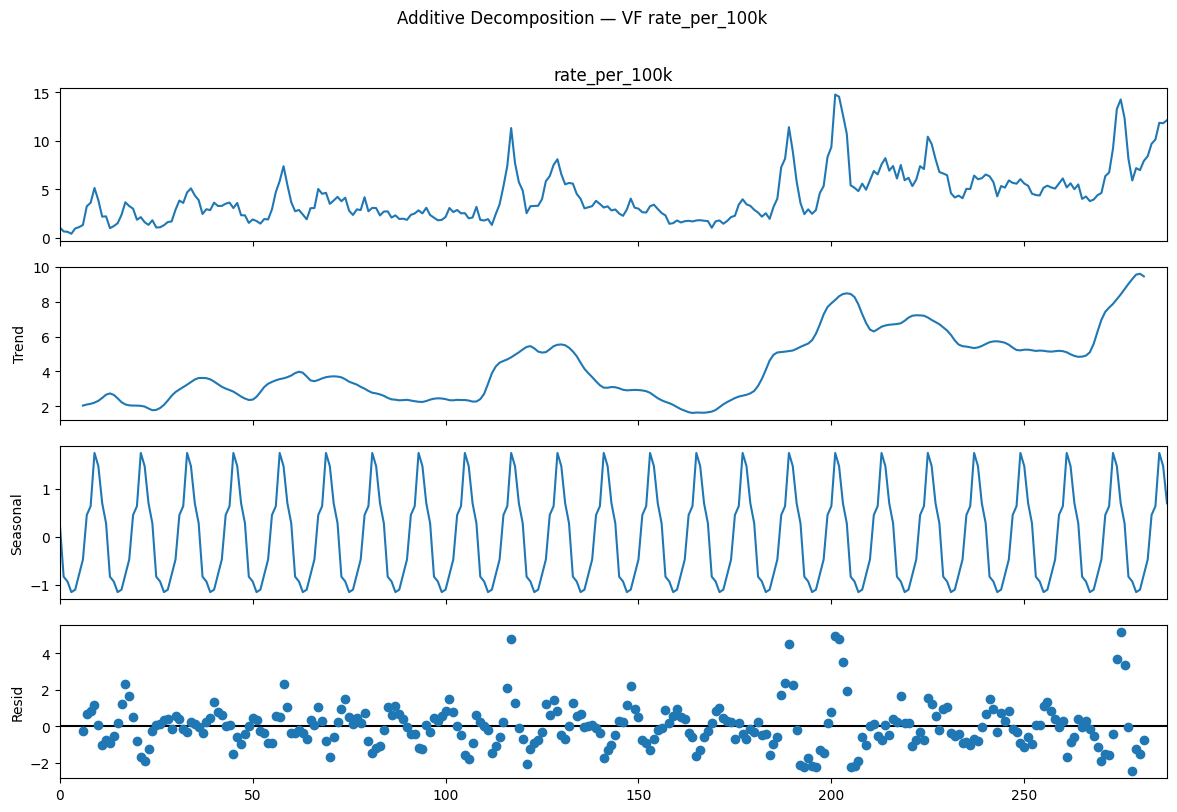

In [ ]:
# period=12 because we have monthly data with annual seasonality
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(monthly_all_df['rate_per_100k'], model='additive', period=12)

fig = result.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Additive Decomposition — VF rate_per_100k', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# pattern evident in the residuals of the original series

/tmp/ipykernel_4861/3846800852.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  monthly_all_df['diff_rate_per_100k'].fillna(method='backfill', inplace=True)
/tmp/ipykernel_4861/3846800852.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  monthly_all_df['diff_rate_per_100k'].fillna(method='backfill', inplace=True)


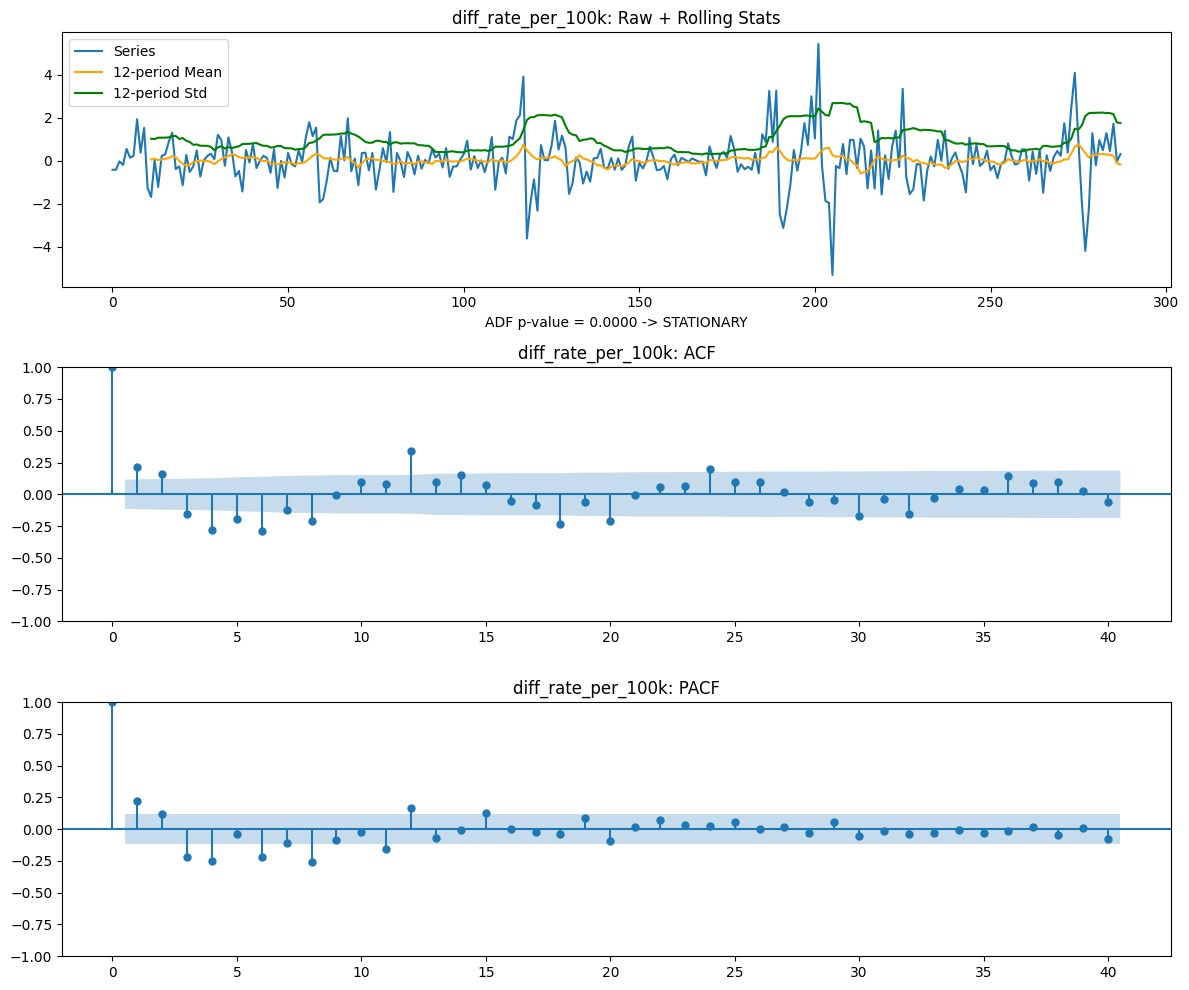

In [ ]:
# diff transform of series
monthly_all_df['diff_rate_per_100k'] = monthly_all_df['rate_per_100k'].diff()
monthly_all_df['diff_rate_per_100k'].fillna(method='backfill', inplace=True)

utils.timeseries_diagnostics(monthly_all_df['diff_rate_per_100k'], label='diff_rate_per_100k', lags=40, rolling_window=12)
# using the diff transform, i found that lag=12 was the best

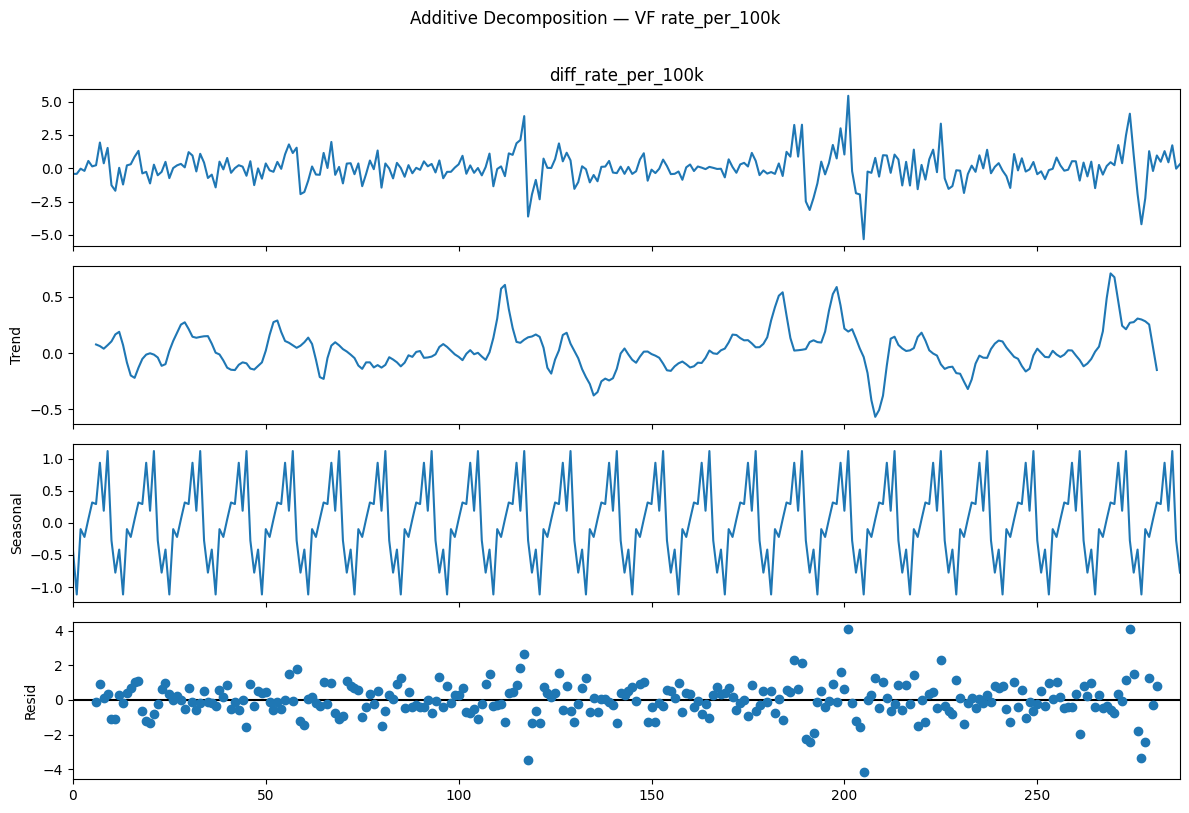

In [ ]:
# period=12 because we have monthly data with annual seasonality
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(monthly_all_df['diff_rate_per_100k'].dropna(), model='a', period=12)

fig = result.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Additive Decomposition — VF rate_per_100k', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# slight pattern still exists in the residuals for the diff_rate

In [ ]:
from statsmodels.tsa.ar_model import AutoReg

p = 12
rate_series = monthly_all_df['diff_rate_per_100k'].dropna()

model = AutoReg(rate_series, lags=p)
result = model.fit()

print(result.summary())

                            AutoReg Model Results                             
Dep. Variable:     diff_rate_per_100k   No. Observations:                  288
Model:                    AutoReg(12)   Log Likelihood                -376.204
Method:               Conditional MLE   S.D. of innovations              0.946
Date:                Thu, 02 Jul 2026   AIC                            780.409
Time:                        16:15:41   BIC                            831.095
Sample:                            12   HQIC                           800.748
                                  288                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      0.0596      0.058      1.035      0.301      -0.053       0.172
diff_rate_per_100k.L1      0.0773      0.059      1.308      0.191      -0.039       0.193
diff

In [ ]:
print('Fitted AR coefficients:')
print(result.params)

# FILL IN: check stability — are all |phi| < 1?
phi_estimates = result.params[1:]  # skip the intercept
print('\nAre all |phi| < 1?', all(abs(phi_estimates) < 1))

Fitted AR coefficients:
const                     0.059578
diff_rate_per_100k.L1     0.077334
diff_rate_per_100k.L2     0.047544
diff_rate_per_100k.L3    -0.255955
diff_rate_per_100k.L4    -0.250659
diff_rate_per_100k.L5    -0.100373
diff_rate_per_100k.L6    -0.176746
diff_rate_per_100k.L7    -0.108874
diff_rate_per_100k.L8    -0.237482
diff_rate_per_100k.L9    -0.036752
diff_rate_per_100k.L10   -0.035378
diff_rate_per_100k.L11   -0.166112
diff_rate_per_100k.L12    0.187617
dtype: float64

Are all |phi| < 1? True


In [ ]:
# performing the AR fit on original series does not give all |phi| < 1

/tmp/ipykernel_4861/1399143786.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  monthly_all_df['seasonal_diff_rate_per_100k'].fillna(method='backfill', inplace=True)
/tmp/ipykernel_4861/1399143786.py:3: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  monthly_all_df['seasonal_diff_rate_per_100k'].fillna(method='backfill', inplace=True)


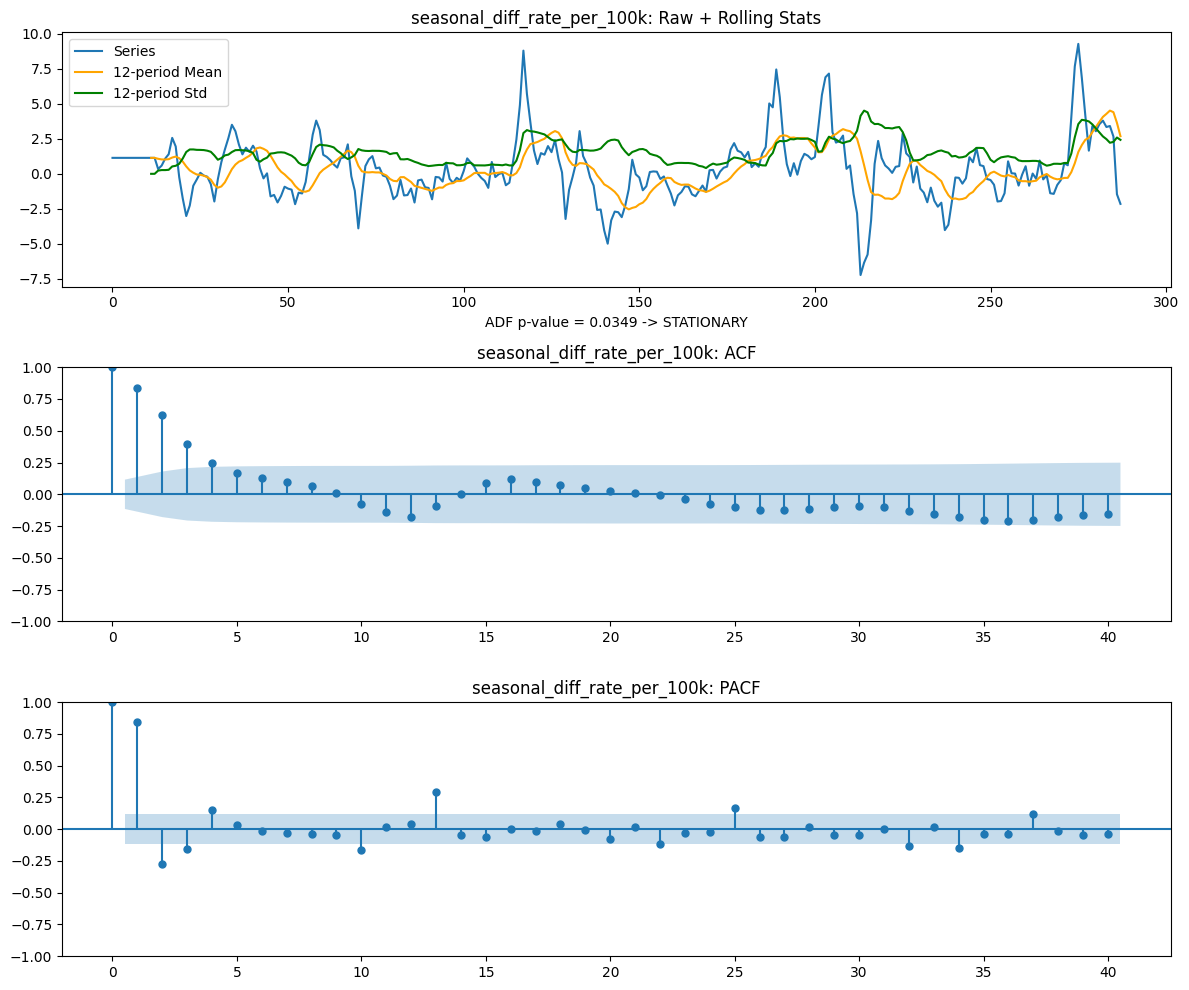

In [ ]:
# seasonal-diff transform of series
monthly_all_df['seasonal_diff_rate_per_100k'] = monthly_all_df['rate_per_100k'].diff(periods=12)
monthly_all_df['seasonal_diff_rate_per_100k'].fillna(method='backfill', inplace=True)

utils.timeseries_diagnostics(monthly_all_df['seasonal_diff_rate_per_100k'], label='seasonal_diff_rate_per_100k', lags=40, rolling_window=12)
# using the seasonal-diff transform, i found that lag=13 was the best

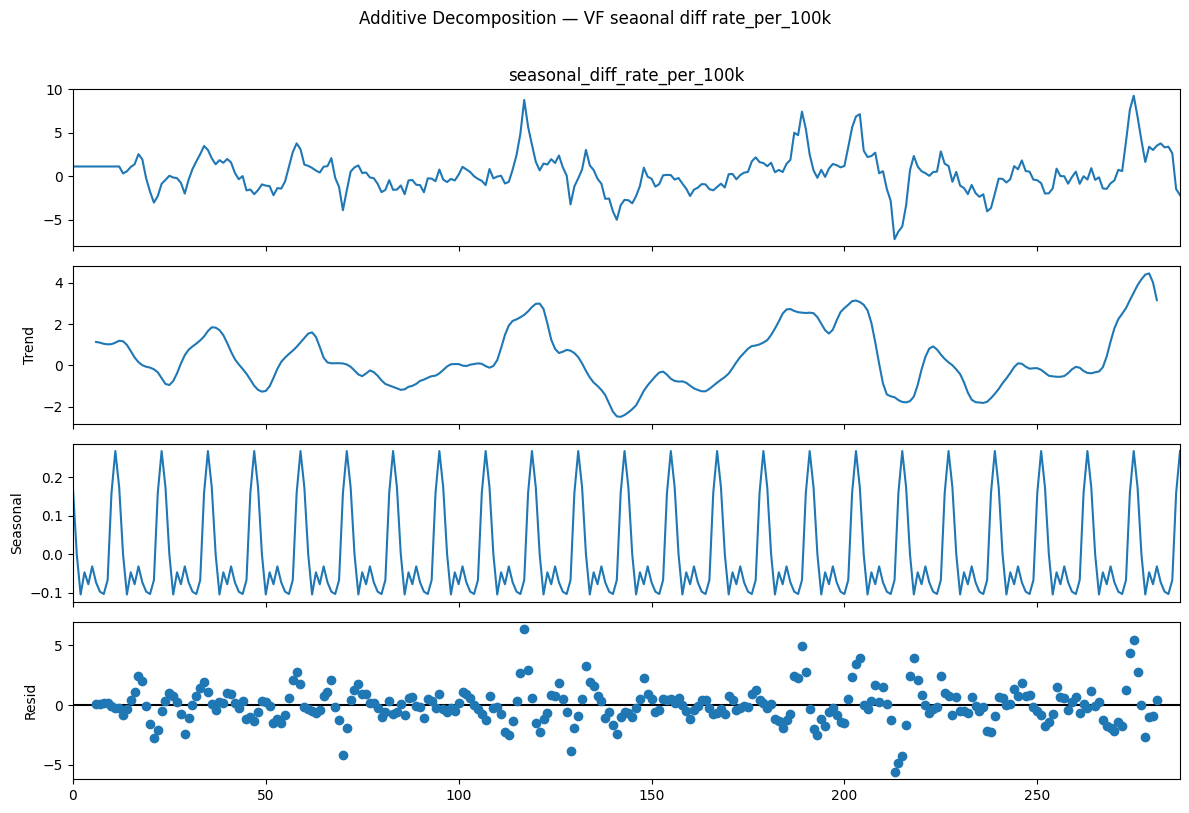

In [ ]:
# period=12 because we have monthly data with annual seasonality
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(monthly_all_df['seasonal_diff_rate_per_100k'].dropna(), model='additive', period=12)

fig = result.plot()
fig.set_size_inches(12, 8)
plt.suptitle('Additive Decomposition — VF seaonal diff rate_per_100k', y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
p = 12
rate_series = monthly_all_df['seasonal_diff_rate_per_100k'].dropna()

model = AutoReg(rate_series, lags=p)
result = model.fit()

print(result.summary())

                                 AutoReg Model Results                                 
Dep. Variable:     seasonal_diff_rate_per_100k   No. Observations:                  288
Model:                             AutoReg(12)   Log Likelihood                -422.016
Method:                        Conditional MLE   S.D. of innovations              1.116
Date:                         Thu, 02 Jul 2026   AIC                            872.032
Time:                                 16:15:50   BIC                            922.718
Sample:                                     12   HQIC                           892.372
                                           288                                         
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const                               0.0724      0.069      1.049      0.294      -0.063       0.

In [ ]:
print('Fitted AR coefficients:')
print(result.params)

# FILL IN: check stability — are all |phi| < 1?
phi_estimates = result.params[1:]  # skip the intercept
print('\nAre all |phi| < 1?', all(abs(phi_estimates) < 1))

Fitted AR coefficients:
const                              0.072355
seasonal_diff_rate_per_100k.L1     1.040703
seasonal_diff_rate_per_100k.L2    -0.042930
seasonal_diff_rate_per_100k.L3    -0.358562
seasonal_diff_rate_per_100k.L4     0.116190
seasonal_diff_rate_per_100k.L5     0.077309
seasonal_diff_rate_per_100k.L6     0.002307
seasonal_diff_rate_per_100k.L7    -0.061462
seasonal_diff_rate_per_100k.L8     0.016122
seasonal_diff_rate_per_100k.L9     0.118194
seasonal_diff_rate_per_100k.L10   -0.155352
seasonal_diff_rate_per_100k.L11   -0.035115
seasonal_diff_rate_per_100k.L12    0.030473
dtype: float64

Are all |phi| < 1? False


In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
sarimax_model = SARIMAX(
    endog=monthly_all_df['rate_per_100k'], # y
    exog=None,
    trend='n',  # controls deterministic trend
                # n = no trend
                # c = constant (intercept)
                # t = linear trend
                # ct = constant+trend
    order=(12,1,1))  # specifies the non-seasonal part of model
                    # p = number of AR terms
                    # d = number of regular differences
                    # q = number of MA terms

In [ ]:
results = sarimax_model.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:          rate_per_100k   No. Observations:                  288
Model:              SARIMAX(12, 1, 1)   Log Likelihood                -390.068
Date:                Wed, 01 Jul 2026   AIC                            810.135
Time:                        18:37:58   BIC                            865.027
Sample:                             0   HQIC                           832.135
                                - 288                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0754      0.095      0.795      0.427      -0.110       0.261
ar.L1         -0.1169      0.320     -0.366      0.715      -0.744       0.510
ar.L2          0.0586      0.055      1.071      0.284      -0.049       0.166
ar.L3         -0.2496      0.060     -4.145      0.000      -0.368      -0.132
ar.L4         -0.3071      0.105     -2.936      0.003      -0.512      -0.102
ar.L5         -0.1563      0.109     -1.428      0.153      -0.371       0.058
ar.L6         -0.2001      0.071     -2.827      0.005      -0.339      -0.061
ar.L7         -0.1514      0.108     -1.400      0.162      -0.363       0.061
ar.L8         -0.2600      0.074     -3.529      0.000      -0.404      -0.116
ar.L9         -0.0934      0.113     -0.826      0.409      -0.315       0.128
ar.L10        -0.0539      0.060     -0.904      0.366      -0.171       0.063
ar.L11        -0.1696      0.067     -2.540      0.011      -0.300      -0.039
ar.L12         0.1577      0.091      1.732      0.083      -0.021       0.336
ma.L1          0.2031      0.316      0.643      0.520      -0.416       0.822
sigma2         0.8801      0.054     16.273      0.000       0.774       0.986
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):               219.63
Prob(Q):                              0.97   Prob(JB):                         0.00
Heteroskedasticity (H):               2.53   Skew:                             1.00
Prob(H) (two-sided):                  0.00   Kurtosis:                         6.79
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [ ]:
pred = results.get_prediction()

pred_mean = pred.predicted_mean

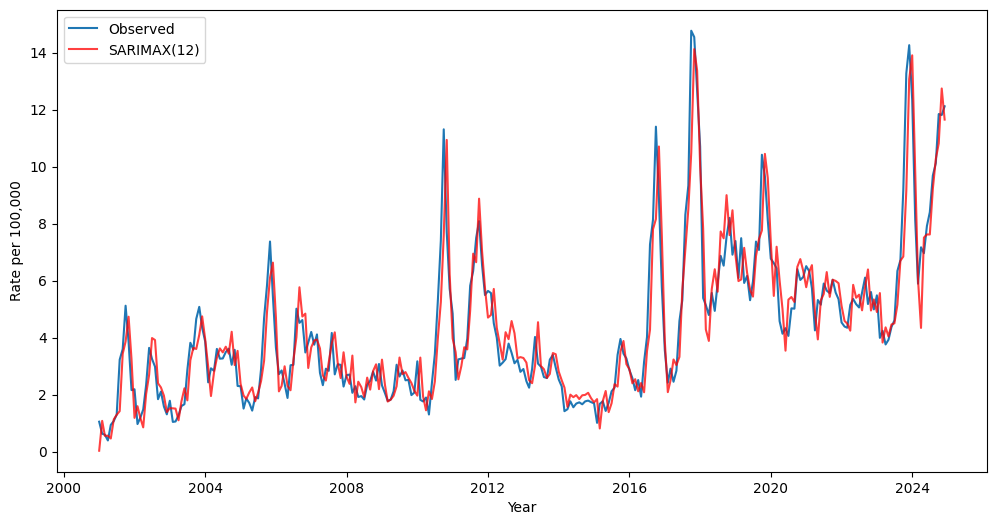

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    monthly_all_df['Year-Month'],
    monthly_all_df["rate_per_100k"],
    label="Observed")

plt.plot(
    monthly_all_df['Year-Month'],
    pred_mean,
    color="red",
    alpha=0.75,
    label="SARIMAX(12)")


plt.xlabel("Year")
plt.ylabel("Rate per 100,000")
plt.legend()
plt.show()

In [ ]:
# in-sample predictions (fitted vals)

In [ ]:
utils.compute_metrics(monthly_all_df['rate_per_100k'], pred_mean)

NameError: name 'pred_mean' is not defined

In [ ]:
# AR-12 Model                           RMSE=0.94008   MAE=0.67581
# AR-24 Model                           RMSE=0.92022   MAE=0.65065

In [ ]:
# using test/train split

In [ ]:
y = monthly_all_df['rate_per_100k']

TRAIN_FRAC = 0.80
split = int(TRAIN_FRAC * len(y))

y_train, y_test = y[:split], y[split:]
train_dates = monthly_all_df["Year-Month"].iloc[:split]
test_dates = monthly_all_df["Year-Month"].iloc[split:]

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# testing model
sarimax_model = SARIMAX(
    endog=y_train, # y
    exog=None,
    trend='n',  # controls deterministic trend
                # None = no trend
                # c = constant (intercept)
                # t = linear trend
                # ct = constant+trend
    order=(0,1,0),    # specifies the non-seasonal part of model
                        # p = number of AR terms
                        # d = number of regular differences
                        # q = number of MA terms
    seasonal_order=(2,0,0,12))

results = sarimax_model.fit()

In [ ]:
forecast = results.get_forecast(steps=len(y_test))

y_pred = forecast.predicted_mean
conf_int = forecast.conf_int()

In [ ]:
import os
print(os.getcwd())

/content/drive/MyDrive/DSSI/Project/code


In [ ]:
sanaa_pred = np.load("pred.npy")

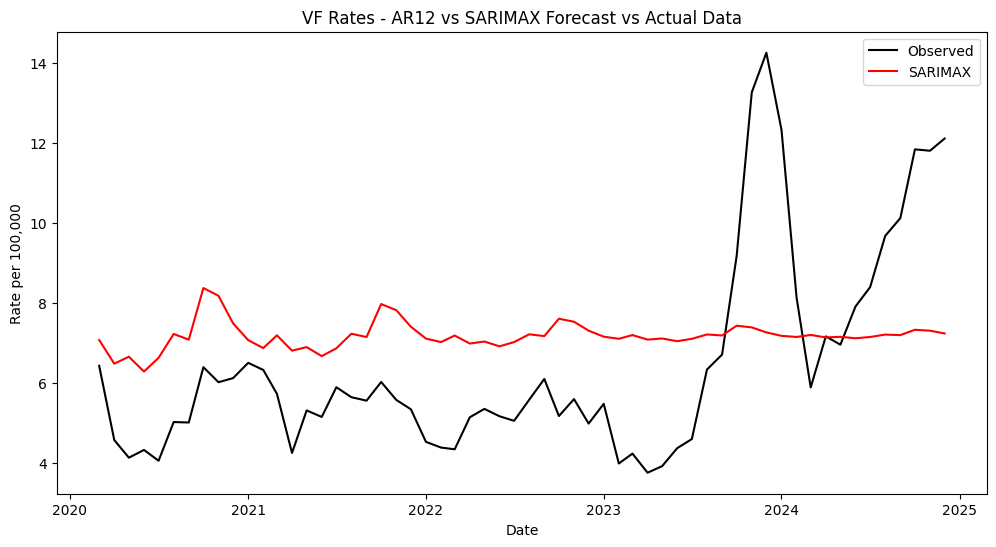

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(test_dates, y_test, label="Observed", color="black")
plt.plot(test_dates, y_pred, label="SARIMAX", color="red")
# plt.plot(test_dates[-56:], sanaa_pred, label="AR(12)", color="blue")

plt.title("VF Rates - AR12 vs SARIMAX Forecast vs Actual Data")
plt.xlabel("Date")
plt.ylabel("Rate per 100,000")
plt.legend()

plt.show()

In [ ]:
utils.compute_metrics(y_test, y_pred)

Model                           RMSE=2.56549   MAE=2.19347


{'RMSE': np.float64(2.5654866242893024), 'MAE': 2.193465846047022}

In [ ]:
# trying auto arima

In [ ]:
!pip install pmdarima
from pmdarima import auto_arima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 21.3 MB/s eta 0:00:00


In [ ]:
auto_model = auto_arima(y_train, exogenous=None, seasonal=True, m=12, trace=True, error_action='ignore', suppress_warnings=True, enforce_stationarity=False, enforce_invertibility=False)

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,0,1)[12] intercept   : AIC=inf, Time=9.13 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=711.959, Time=0.05 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=672.355, Time=1.32 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=682.043, Time=0.80 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=710.064, Time=0.03 sec
 ARIMA(1,1,0)(0,0,0)[12] intercept   : AIC=706.210, Time=0.13 sec
 ARIMA(1,1,0)(2,0,0)[12] intercept   : AIC=672.361, Time=0.46 sec
 ARIMA(1,1,0)(1,0,1)[12] intercept   : AIC=inf, Time=0.89 sec
 ARIMA(1,1,0)(0,0,1)[12] intercept   : AIC=680.278, Time=0.15 sec
 ARIMA(1,1,0)(2,0,1)[12] intercept   : AIC=inf, Time=3.06 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=677.155, Time=0.13 sec
 ARIMA(2,1,0)(1,0,0)[12] intercept   : AIC=672.187, Time=0.25 sec
 ARIMA(2,1,0)(0,0,0)[12] intercept   : AIC=702.795, Time=0.07 sec
 ARIMA(2,1,0)(2,0,0)[12] intercept   : AIC=672.058, Time=0.64 sec
 ARIMA(2,1,0)(2,0,1)[12] intercept   : AIC=in

In [ ]:
print(auto_model.summary())

                                        SARIMAX Results                                        
Dep. Variable:                                       y   No. Observations:                  230
Model:             SARIMAX(4, 1, 1)x(1, 0, [1, 2], 12)   Log Likelihood                -306.664
Date:                                 Thu, 02 Jul 2026   AIC                            633.328
Time:                                         16:52:56   BIC                            667.665
Sample:                                              0   HQIC                           647.180
                                                 - 230                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0005      0.001      0.382      0.702      -0.002       0

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# testing model
sarimax_model = SARIMAX(
    endog=y_train, # y
    exog=None,
    trend='n',  # controls deterministic trend
                # None = no trend
                # c = constant (intercept)
                # t = linear trend
                # ct = constant+trend
    order=(4,1,1),    # specifies the non-seasonal part of model
                        # p = number of AR terms
                        # d = number of regular differences
                        # q = number of MA terms
    seasonal_order=(1,0,1,12))

results = sarimax_model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
forecast = results.get_forecast(steps=len(y_test))

y_pred = forecast.predicted_mean
conf_int = forecast.conf_int()

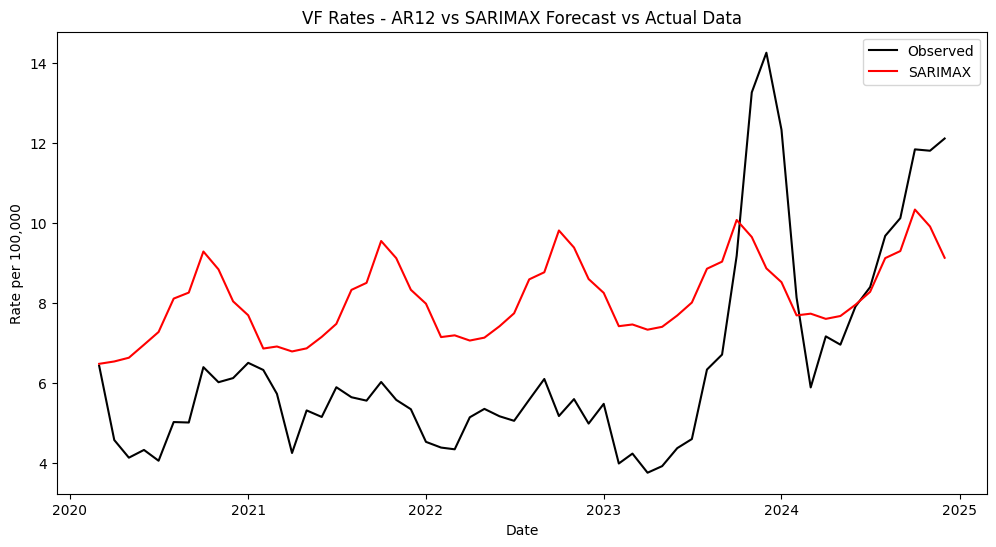

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(test_dates, y_test, label="Observed", color="black")
plt.plot(test_dates, y_pred, label="SARIMAX", color="red")
# plt.plot(test_dates[-56:], sanaa_pred, label="AR(12)", color="blue")

plt.title("VF Rates - AR12 vs SARIMAX Forecast vs Actual Data")
plt.xlabel("Date")
plt.ylabel("Rate per 100,000")
plt.legend()

plt.show()

In [ ]:
utils.compute_metrics(y_test, y_pred)

Model                           RMSE=2.67418   MAE=2.40052


{'RMSE': np.float64(2.674181049333413), 'MAE': 2.4005179035781405}